In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from anonymeter.evaluators import SinglingOutEvaluator
from anonymeter.evaluators import LinkabilityEvaluator
from anonymeter.evaluators import InferenceEvaluator 
import sys
parent_dir = "/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline"
sys.path.append(parent_dir)

In [2]:
import logging
logging.basicConfig(filename="anonymeter_singlingout.log", level=logging.DEBUG)

In [3]:
ori = pd.read_csv("OriginalData/integrated_data_final.csv", index_col = 0)
syn = pd.read_csv("SyntheticData/synthetic_data_gauss_copula.csv", index_col = 0)

In [4]:
ori.columns = [col.replace('.', '_') for col in ori.columns]
syn.columns = [col.replace('.', '_') for col in syn.columns]

In [ ]:
from SynOmics.utils.monitoring import monitor_resources
import numpy as np
seed_value = 42
rng = np.random.default_rng(seed_value)
max_attempts = 1_000_000
n_cols_to_try = [1000, 5000, 10000, 40992] 
@monitor_resources
def singling_out(ori, syn, n_cols_to_try, max_attempts):
    risk_dict= {}
    evaluators_dict = {}
    for n_col in n_cols_to_try:
        print(f"----{n_col}---")
        ori_test = ori.iloc[:, 0: n_col]
        syn_test = syn.iloc[:,0:n_col]
        evaluator = SinglingOutEvaluator(ori=ori_test, 
                                     syn=syn_test, 
                                     n_attacks=1000
                                        )
        evaluator.evaluate(mode="univariate")
        risk = evaluator.risk()
        risk_dict[str(n_col)] = risk
        evaluators_dict[n_col] = evaluator
        print(f"Risk of this configuration {risk}")
    return evaluators_dict, risk_dict
    
evaluator_singling, singlingout_risk = singling_out(ori, syn, n_cols_to_try, max_attempts)

In [6]:
res = evaluator_singling.results()

print("Successs rate of main attack:", res.attack_rate)
print("Successs rate of baseline attack:", res.baseline_rate)
print("Successs rate of control attack:", res.control_rate)

Successs rate of main attack: SuccessRate(value=0.009306384890390635, error=0.008736723704897366)
Successs rate of baseline attack: SuccessRate(value=0.009306384890390635, error=0.008736723704897366)
Successs rate of control attack: None


In [48]:
from SynOmics.utils.monitoring import monitor_resources
ori_proto = ori.iloc[:,0:]
syn_proto = syn.iloc[:,0:] 
@monitor_resources
def linkability_attack(ori, syn, n_attack, aux_cols, n_neighbors):
    

    evaluator = LinkabilityEvaluator(ori=ori, 
                                     syn=syn, 
                                     n_attacks=n_attack,
                                     aux_cols=aux_cols,
                                     n_neighbors=n_neighbors)
    

    evaluator.evaluate(n_jobs=-2)  # n_jobs follow j0oblib convention. -1 = all cores, -2 = all execept one
    print(evaluator.risk())
    return evaluator
n_attack = ori_proto.shape[0]
aux_cols = [ori_proto.columns[0:22].tolist(),
            ori_proto.columns[22:].tolist()]
n_neighbors = 10
link_eva = linkability_attack(ori_proto, syn_proto, n_attack, aux_cols, n_neighbors)

--- System & Process Info ---
Current Date and Time (UTC): 2025-10-10 21:51:12
Current User's Login: trinhtc
CPU Model: x86_64
Physical Cores: 32
Logical Processors: 32
Process RAM before execution: 1263.14 MB

--- GPU Info ---
GPU monitoring failed. Ensure 'pynvml' is installed and NVIDIA drivers are accessible.
Error: NVML Shared Library Not Found

--- Function Execution ---
PrivacyRisk(value=0.44264620083134437, ci=(0.3876983251729906, 0.49759407648969817))

--- Resource Usage Summary ---
Execution time: 39.579661 seconds
Process RAM after execution: 1265.78 MB
Process RAM used by function: 2.64 MB
Average per-core CPU during execution: [88.5, 15.6, 4.3, 3.9, 10.4, 3.8, 10.2, 3.8, 12.5, 2.9, 16.4, 3.1, 2.2, 3.2, 4.1, 3.6, 4.1, 3.6, 4.1, 3.7, 10.3, 3.7, 9.6, 3.8, 4.1, 3.9, 11.0, 3.7, 11.4, 3.7, 4.1, 3.9]
CPU Cores utilized (>10%): 9 of 32




In [50]:
res = link_eva.results()

print("Successs rate of main attack:", res.attack_rate)
print("Successs rate of baseline attack:", res.baseline_rate)
print("Successs rate of control attack:", res.control_rate)

Successs rate of main attack: SuccessRate(value=0.44264620083134437, error=0.05494787565835378)
Successs rate of baseline attack: SuccessRate(value=0.24509422591708604, error=0.047485258457578935)
Successs rate of control attack: None


In [51]:
from tqdm import tqdm

@monitor_resources
def inference_attack(ori, syn, n_attacks):
    columns = ori.columns
    results = []
    for secret in tqdm(columns):
        aux_cols = [col for col in columns if col != secret]        
        evaluator = InferenceEvaluator(ori=ori, 
                                       syn=syn, 
                                       aux_cols=aux_cols,
                                       secret=secret,
                                       n_attacks=n_attacks)
        evaluator.evaluate(n_jobs=-2)
        results.append((secret, evaluator.results()))
    return results

ori_proto = ori.iloc[:,0:1000]
syn_proto = syn.iloc[:,0:1000]
n_attacks = ori_proto.shape[0]
inferences_results = inference_attack(ori_proto, syn_proto, n_attacks)

--- System & Process Info ---
Current Date and Time (UTC): 2025-10-10 22:01:08
Current User's Login: trinhtc
CPU Model: x86_64
Physical Cores: 32
Logical Processors: 32
Process RAM before execution: 1071.11 MB

--- GPU Info ---
GPU monitoring failed. Ensure 'pynvml' is installed and NVIDIA drivers are accessible.
Error: NVML Shared Library Not Found

--- Function Execution ---


  0%|▉                                                                                                                                                                                                                                       | 4/1000 [00:01<06:10,  2.69it/s]/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/anonymeter/stats/confidence.py:218: UserWarning: Attack is as good or worse as baseline model. Estimated rates: attack = 0.5955896652810927, baseline = 0.605148631809202. Analysis results cannot be trusted.
  self._sanity_check()
  0%|█▏                                                                                                                                                                                                                                      | 5/1000 [00:01<06:12,  2.67it/s]/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/anonymeter/stats/confidence.py:218: UserWarning: Attack is as good or worse as baseline model. E


--- Resource Usage Summary ---
Execution time: 389.839821 seconds
Process RAM after execution: 1073.63 MB
Process RAM used by function: 2.52 MB
Average per-core CPU during execution: [2.1, 15.8, 2.3, 12.3, 15.7, 10.9, 19.1, 10.4, 15.5, 11.4, 18.0, 10.8, 2.1, 10.8, 2.2, 10.7, 1.5, 10.2, 1.7, 9.8, 17.8, 12.4, 17.3, 11.8, 1.5, 10.9, 21.6, 10.6, 19.9, 10.5, 1.3, 10.3]
CPU Cores utilized (>10%): 23 of 32




In [80]:
print(inferences_results[3][1].baseline_rate)
print(inferences_results[3][1].attack_rate)

SuccessRate(value=0.6306392092174934, error=0.053371765767358664)
SuccessRate(value=0.7517194519068775, error=0.047695424317433725)


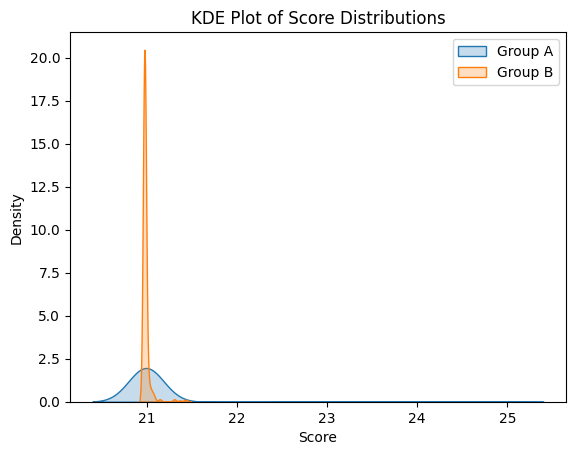

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns
a = ori.iloc[:,40].values
b = syn.iloc[:,40].values

sns.kdeplot(a, label='Group A', fill=True)
sns.kdeplot(b, label='Group B', fill=True)

plt.title('KDE Plot of Score Distributions')
plt.xlabel('Score')
plt.ylabel('Density')
plt.legend()
plt.show()



In [96]:
np.random.rand(100, 5)

array([[1.67135077e-01, 6.29042297e-01, 1.61471500e-01, 8.89957424e-02,
        7.90346403e-01],
       [6.24048599e-01, 6.88005544e-02, 8.36346933e-04, 9.34268892e-02,
        2.34937637e-01],
       [3.68350751e-01, 6.52761936e-01, 6.75284179e-01, 4.14657493e-01,
        1.24474802e-01],
       [4.96477279e-01, 1.61883590e-01, 8.24092526e-02, 4.60829433e-01,
        9.53433236e-01],
       [3.05128870e-01, 5.69730289e-01, 7.14444711e-01, 6.62307720e-02,
        9.97913619e-01],
       [2.71777875e-01, 6.34362745e-01, 8.55615430e-01, 6.18792047e-01,
        2.37465211e-02],
       [6.79972758e-01, 9.45136720e-01, 2.11736572e-01, 8.18856162e-01,
        1.91753110e-01],
       [3.77113149e-01, 8.51412706e-01, 7.76344527e-01, 5.50310293e-01,
        2.29160021e-02],
       [4.49413814e-01, 7.58510726e-01, 8.28822115e-01, 3.13750584e-01,
        1.70805356e-01],
       [5.42889448e-01, 3.82170124e-01, 1.17381815e-01, 5.07064544e-02,
        6.50892130e-01],
       [8.66974154e-01, 3.3957